In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.collector import YouTubeCollector
from src.niche_analyzer import NicheAnalyzer
from config import MAX_VIDEOS_PER_CHANNEL

POPULAR_NICHE = {
    "name": "Personal Finance India",
    "channels": [
        "UCwAdQUuPT6laN-AQR17fe1g",
        "UCe3qdG0A_gr-sEdat5y2twQ",
        "UCVOTBwF0vnSxMRIbfSE_K_g",
        "UCwVEhEzsjLym_u1he4XWFkg",
        "UCqW8jxh4tH1Z1sWPbkGWL4g"
    ]
}

UNDERSERVED_NICHE = {
    "name": "India Economy and Data Stories",
    "channels": [
        "UCIfANh2BltdF-XixRwKFRqQ",
        "UC_gUM8rL-Lrg6O3adPW9K1g",
        "UCKZozRVHRYsYHGEyNKuhhdA",
        "UCNXapAc8mXTwW82MTncdfzQ",
        "UCR-foyF-C6VuAlwy3KZMkgA"
    ]
}


In [2]:
# Cell 2 — Collect data for both niches
collector = YouTubeCollector()

popular_df = collector.collect_niche(
    POPULAR_NICHE,
    max_videos_per_channel=MAX_VIDEOS_PER_CHANNEL
)
popular_df.to_csv("../data/raw/popular_niche/videos.csv", index=False)
print(f"Popular niche: {len(popular_df)} videos saved")


Channels: 5
→ Fetching channel info...
  → Akshat Shrivastava (2,270,000 subs)
     Found 500 videos
  → Finance With Sharan (3,720,000 subs)
     Found 500 videos
  → Pranjal Kamra (6,490,000 subs)
     Found 421 videos
  → Labour Law Advisor (5,440,000 subs)
     Found 500 videos
  → CA Rachana Phadke Ranade (5,390,000 subs)
     Found 500 videos

Total videos collected: 2421
Quota used this session: 99 units
Popular niche: 2421 videos saved


In [3]:
# Cell 3
underserved_df = collector.collect_niche(
    UNDERSERVED_NICHE,
    max_videos_per_channel=MAX_VIDEOS_PER_CHANNEL
)
underserved_df.to_csv("../data/raw/underserved_niche/videos.csv", index=False)
print(f"Underserved niche: {len(underserved_df)} videos saved")


Channels: 5
→ Fetching channel info...
  → Think School (5,950,000 subs)
     Found 500 videos
  → WION (10,400,000 subs)
     Found 500 videos
  → Dr. Vivek Bindra: Motivational Speaker (21,100,000 subs)
     Found 500 videos
  → 1 Finance (14,200 subs)
     Found 500 videos
  → Finology (353,000 subs)
     Found 392 videos

Total videos collected: 2392
Quota used this session: 196 units
Underserved niche: 2392 videos saved


In [4]:
# Cell 4 — Score both niches
popular_analyzer = NicheAnalyzer(popular_df, "Personal Finance India")
underserved_analyzer = NicheAnalyzer(underserved_df, "India Economy Data Stories")

popular_score = popular_analyzer.score_niche()
underserved_score = underserved_analyzer.score_niche()

comparison = pd.DataFrame([popular_score, underserved_score])
print("\n=== NICHE COMPARISON ===")
print(comparison.T.to_string())


=== NICHE COMPARISON ===
                                                           0                           1
niche                                 Personal Finance India  India Economy Data Stories
videos_analysed                                         1853                        1066
demand_score_median_views                             217431                       22064
new_creator_opportunity_median_views                       0                         364
competition_videos_per_month                            22.0                        14.9
viral_potential_pct                                     2.37                        13.7
engagement_rate_pct                                    3.295                       3.294
opportunity_ratio                                       9876                        1478


In [5]:
# Cell 5 — What features do top videos share?
print("\n=== POPULAR NICHE — TOP VIDEO FEATURES ===")
popular_features = popular_analyzer.best_performing_features()
for k, v in popular_features.items():
    print(f"  {k}: {v}")

print("\n=== UNDERSERVED NICHE — TOP VIDEO FEATURES ===")
underserved_features = underserved_analyzer.best_performing_features()
for k, v in underserved_features.items():
    print(f"  {k}: {v}")


=== POPULAR NICHE — TOP VIDEO FEATURES ===
  top_videos_avg_duration_mins: 12.3
  bottom_videos_avg_duration_mins: 16.1
  top_videos_pct_with_number_in_title: 65.9
  bottom_videos_pct_with_number_in_title: 49.6
  top_videos_avg_title_length: 57.7
  bottom_videos_avg_title_length: 61.8
  best_upload_hour_ist: 20
  best_upload_day: 5
  top_videos_avg_tags_count: 12.1

=== UNDERSERVED NICHE — TOP VIDEO FEATURES ===
  top_videos_avg_duration_mins: 22.2
  bottom_videos_avg_duration_mins: 6.8
  top_videos_pct_with_number_in_title: 26.7
  bottom_videos_pct_with_number_in_title: 22.8
  top_videos_avg_title_length: 62.5
  bottom_videos_avg_title_length: 65.5
  best_upload_hour_ist: 18
  best_upload_day: 3
  top_videos_avg_tags_count: 15.8


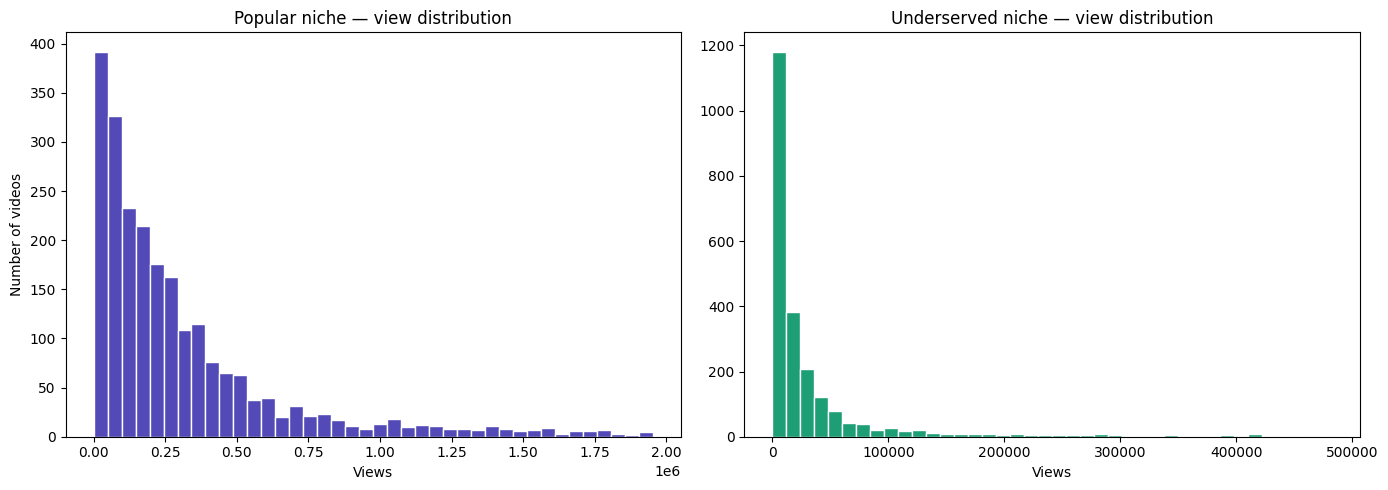

In [6]:
# Cell 6 — Visualise view distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    popular_df[popular_df["view_count"] < popular_df["view_count"].quantile(0.95)]["view_count"],
    bins=40, color="#534AB7", edgecolor="white"
)
axes[0].set_title("Popular niche — view distribution")
axes[0].set_xlabel("Views")
axes[0].set_ylabel("Number of videos")

axes[1].hist(
    underserved_df[underserved_df["view_count"] < underserved_df["view_count"].quantile(0.95)]["view_count"],
    bins=40, color="#1D9E75", edgecolor="white"
)
axes[1].set_title("Underserved niche — view distribution")
axes[1].set_xlabel("Views")

plt.tight_layout()
plt.savefig("../reports/niche_view_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Cell 7 — Save comparison to reports
comparison.to_csv("../data/processed/niche_comparison.csv", index=False)
print("\nNiche comparison saved to data/processed/niche_comparison.csv")
print(f"\nTotal API quota used: {collector.quota_used} units")


Niche comparison saved to data/processed/niche_comparison.csv

Total API quota used: 196 units
